# 01 · Erstes CNN in PyTorch – didaktisch aufbereitet

**Vom Klick in der App zum Code.** In der App
[CNN Grayscale Trainer](https://iludis.de/CNN_sim/CNN_sim.html) habt ihr gesehen,
was ein Faltungskern (*Kernel*) mit einem Graustufenbild macht: Er gleitet darüber
und erzeugt eine **Feature Map**. Dieses Notebook baut genau diese Pipeline in
PyTorch nach – und zeigt jeden Zwischenschritt als Bild.

**Datensatz:** `load_digits` aus sklearn – handgeschriebene Ziffern als
**8×8-Graustufenbilder**. Klein genug, dass wir jeden einzelnen Pixel- und
Feature-Map-Wert ausdrucken können – also volle Transparenz, genau wie in der App.

**Roter Faden des Notebooks:**
1. Daten ansehen (Bild = Zahlenmatrix)
2. CNN als `nn.Sequential` aufbauen und per Slicing in Stufen zerlegen
3. Tensor-**Formen** Schritt für Schritt verfolgen
4. Trainieren
5. Die **Pipeline sichtbar machen** (App-Nachbau): Kernel → Faltung → ReLU → Pooling
6. Was hat das Netz gelernt? (Kernel vorher/nachher, Verwechslungen)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Reproduzierbarkeit: alle sehen dieselben Zufallswerte und Visualisierungen
torch.manual_seed(42)
np.random.seed(42)

# Haus-Stil (LFB KI BW)
DUNKELBLAU = "#1B3A5C"
MITTELBLAU = "#2E75B6"
plt.rcParams["font.family"]  = "DejaVu Sans"   # Arial-nah (Arial oft nicht installiert)
plt.rcParams["axes.titlecolor"] = DUNKELBLAU
plt.rcParams["figure.dpi"]   = 110

## 1 · Daten ansehen – ein Bild ist eine Zahlenmatrix

Die Werte liegen ursprünglich zwischen 0 und 16. Wir teilen durch 16, damit sie –
wie Graustufen in der App – zwischen 0 (schwarz) und 1 (weiß) liegen. Die zusätzliche
Dimension `1` steht für **einen** Farbkanal (grau).

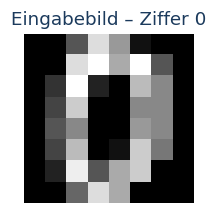

Dieselben Pixel als 8x8-Zahlenmatrix (gerundet):
[[0.   0.   0.31 0.81 0.56 0.06 0.   0.  ]
 [0.   0.   0.81 0.94 0.62 0.94 0.31 0.  ]
 [0.   0.19 0.94 0.12 0.   0.69 0.5  0.  ]
 [0.   0.25 0.75 0.   0.   0.5  0.5  0.  ]
 [0.   0.31 0.5  0.   0.   0.56 0.5  0.  ]
 [0.   0.25 0.69 0.   0.06 0.75 0.44 0.  ]
 [0.   0.12 0.88 0.31 0.62 0.75 0.   0.  ]
 [0.   0.   0.38 0.81 0.62 0.   0.   0.  ]]


In [2]:
digits = load_digits()
X = digits.images            # Form: (1797, 8, 8) – Graustufen, Werte 0..16
y = digits.target            # Ziffer 0..9

X = X / 16.0                 # auf 0..1 normieren (wie Graustufen in der App)
X = np.expand_dims(X, axis=1)   # Form: (1797, 1, 8, 8) -> 1 Kanal (grau)

beispiel = 0
plt.figure(figsize=(2, 2))
plt.imshow(X[beispiel, 0], cmap="gray")
plt.title(f"Eingabebild – Ziffer {y[beispiel]}")
plt.axis("off")
plt.show()

print("Dieselben Pixel als 8x8-Zahlenmatrix (gerundet):")
print(np.round(X[beispiel, 0], 2))

## 2 · Trainings-/Testdaten und Umwandlung in Tensoren

Ein CNN erwartet die Form **(Bilder, Kanal, Höhe, Breite)** – genau die haben wir
schon. Wir wandeln nur noch in PyTorch-Tensoren um.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print(f"X_train: {tuple(X_train.shape)}   (Bilder, Kanal, Höhe, Breite)")
print(f"X_test : {tuple(X_test.shape)}")
print(f"y_train: {tuple(y_train.shape)}        (Klassenlabels 0..9)")

X_train: (1437, 1, 8, 8)   (Bilder, Kanal, Höhe, Breite)
X_test : (360, 1, 8, 8)
y_train: (1437,)        (Klassenlabels 0..9)


## 3 · Das CNN als `nn.Sequential`

Wir bauen das Netz als einfachen **Stapel von Schichten** (`nn.Sequential`) – ein
Netz ist im Kern nichts anderes als eine *geordnete Liste* von Schichten. An die
Zwischenergebnisse kommen wir trotzdem heran, denn ein `nn.Sequential` ist
**schneidbar**: `net[:k]` wendet nur die ersten `k` Schichten an. So holen wir uns
später die Feature Maps nach Faltung, ReLU und Pooling.

Die Schichten sind durchnummeriert – `net[0]` ist die Faltung. Genau dieses Element
brauchen wir, um die Anfangs-Kernel für den späteren Vorher/Nachher-Vergleich zu
sichern.

> *Wann lohnt sich stattdessen eine eigene `nn.Module`-Klasse? Sobald ein Netz
> benannte Teile oder Verzweigungen hat (z. B. Skip-Connections). Für einen reinen
> Schichtstapel wie hier ist `nn.Sequential` die schlankere Wahl.*

In [4]:
net = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),  # 0: 1x8x8 -> 8x8x8
    nn.ReLU(),                                  # 1
    nn.MaxPool2d(2),                            # 2: 8x8x8 -> 8x4x4
    nn.Flatten(),                               # 3: 8*4*4 = 128
    nn.Linear(8 * 4 * 4, 32),                   # 4
    nn.ReLU(),                                  # 5
    nn.Linear(32, 10),                          # 6: 10 Ziffern
)
print(net)

total = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"\nTrainierbare Parameter insgesamt: {total}")

# Conv-Layer ist Element 0. Anfangs-Kernel sichern (Kopie!) für Vorher/Nachher.
kernel_vorher = net[0].weight.detach().clone()

Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=128, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=10, bias=True)
)

Trainierbare Parameter insgesamt: 4538


## 4 · Tensor-Formen Schritt für Schritt verfolgen

Die häufigste Hürde bei CNNs sind die **Dimensionen**. Schicken wir *ein* Bild durch
das Netz und sehen zu, wie sich die Form nach jeder Stufe ändert:

`1×8×8` → Faltung `8×8×8` → MaxPool `8×4×4` → flach `128` → `32` → `10`

In [5]:
beispiel_bild = X_train[0:1]    # Form (1, 1, 8, 8): ein einzelnes Bild

# Per Slicing nach jeder Stufe "anhalten":
with torch.no_grad():
    nach_conv = net[:1](beispiel_bild)   # nach Faltung   (= net[0])
    nach_relu = net[:2](beispiel_bild)   # nach ReLU
    nach_pool = net[:3](beispiel_bild)   # nach MaxPool

print(f"{'Stufe':<24}{'Form (Kanal x H x B)'}")
print("-" * 46)
print(f"{'Eingabe':<24}{tuple(beispiel_bild.shape[1:])}")
print(f"{'Faltung (Conv2d)':<24}{tuple(nach_conv.shape[1:])}")
print(f"{'nach ReLU':<24}{tuple(nach_relu.shape[1:])}")
print(f"{'nach MaxPool':<24}{tuple(nach_pool.shape[1:])}")
print(f"{'flach (Flatten)':<24}{(8 * 4 * 4,)}")
print(f"{'Ausgabe (10 Klassen)':<24}{(10,)}")

Stufe                   Form (Kanal x H x B)
----------------------------------------------
Eingabe                 (1, 8, 8)
Faltung (Conv2d)        (8, 8, 8)
nach ReLU               (8, 8, 8)
nach MaxPool            (8, 4, 4)
flach (Flatten)         (128,)
Ausgabe (10 Klassen)    (10,)


## 5 · Training

Klein und einfach gehalten: Full-Batch (alle Bilder pro Schritt), Adam, 30 Epochen.
Das genügt für die 8×8-Ziffern völlig. *(Batching, Early Stopping und
Speichern/Laden kommen im Folge-Notebook „04".)*

Epoche  0 | Loss: 2.3113
Epoche  5 | Loss: 2.1215
Epoche 10 | Loss: 1.6812


Epoche 15 | Loss: 1.0296
Epoche 20 | Loss: 0.5588
Epoche 25 | Loss: 0.3413


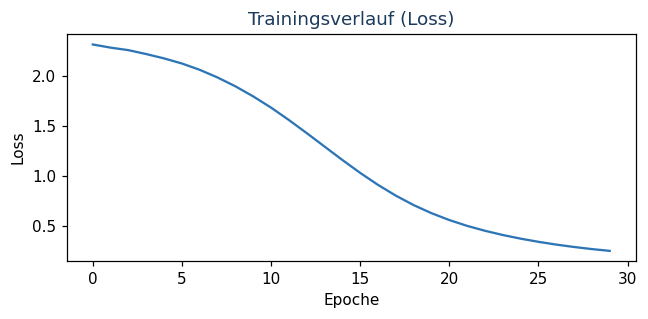

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

verlauf = []
net.train()
for epoch in range(30):
    optimizer.zero_grad()
    outputs = net(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    verlauf.append(loss.item())
    if epoch % 5 == 0:
        print(f"Epoche {epoch:2d} | Loss: {loss.item():.4f}")

plt.figure(figsize=(6, 3))
plt.plot(verlauf, color=MITTELBLAU)
plt.title("Trainingsverlauf (Loss)")
plt.xlabel("Epoche"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

In [7]:
net.eval()
with torch.no_grad():
    outputs   = net(X_test)
    predicted = torch.argmax(outputs, dim=1)
    acc = accuracy_score(y_test.numpy(), predicted.numpy())
print(f"Testgenauigkeit: {acc * 100:.2f}%")

Testgenauigkeit: 92.78%


## 6 · Die Pipeline sichtbar machen (App-Nachbau)

Jetzt das Herzstück: Wir schicken **ein** Testbild durch das trainierte Netz und
zeigen jede Stufe als Bild – dieselbe Abfolge wie in der App:

**Eingabe → Kernel → Faltung → ReLU → MaxPool**

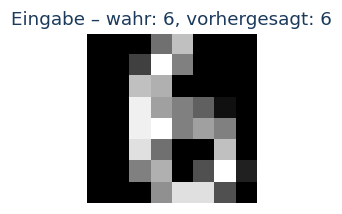

In [8]:
idx  = 0
bild = X_test[idx:idx + 1]

net.eval()
with torch.no_grad():
    logits = net(bild)
    # Zwischenstufen per Slicing – gleiche Schlüssel wie zuvor,
    # damit zeige_maps() unten unverändert funktioniert
    stufen = {
        "Faltung (Conv2d)": net[:1](bild),
        "nach ReLU":        net[:2](bild),
        "nach MaxPool":     net[:3](bild),
    }
pred = torch.argmax(logits, dim=1).item()

plt.figure(figsize=(2, 2))
plt.imshow(bild[0, 0], cmap="gray")
plt.title(f"Eingabe – wahr: {y_test[idx].item()}, vorhergesagt: {pred}")
plt.axis("off"); plt.show()

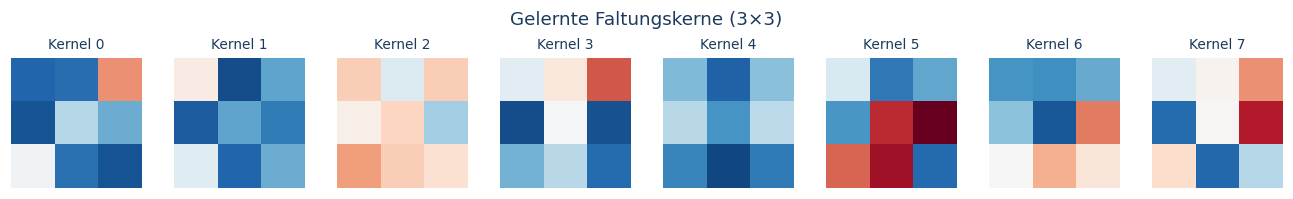

In [9]:
# Die 8 gelernten Kernel (3x3) – das sind die "Filter" aus der App.
# Rot = positives Gewicht, Blau = negatives Gewicht.
kernel = net[0].weight.detach()        # Conv-Layer = Element 0; Form (8, 1, 3, 3)
grenze = kernel.abs().max().item()

fig, axs = plt.subplots(1, 8, figsize=(12, 1.8))
for i in range(8):
    axs[i].imshow(kernel[i, 0], cmap="RdBu", vmin=-grenze, vmax=grenze)
    axs[i].set_title(f"Kernel {i}", fontsize=9)
    axs[i].axis("off")
fig.suptitle("Gelernte Faltungskerne (3×3)", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

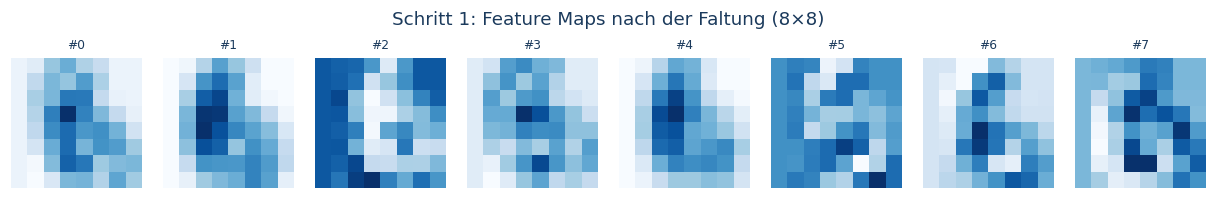

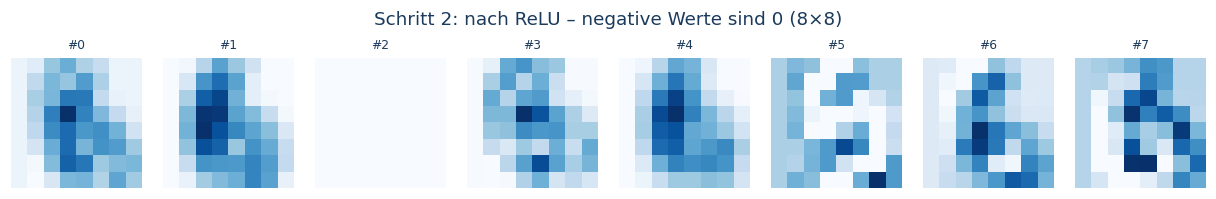

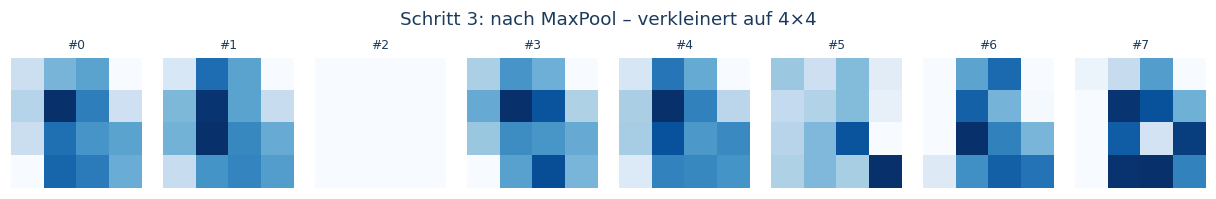

In [10]:
def zeige_maps(tensor, titel, cmap="Blues"):
    '''Zeigt alle Kanäle (Feature Maps) eines Tensors (1, K, H, B) nebeneinander.'''
    n = tensor.shape[1]
    fig, axs = plt.subplots(1, n, figsize=(1.4 * n, 1.8))
    for i in range(n):
        axs[i].imshow(tensor[0, i], cmap=cmap)
        axs[i].set_title(f"#{i}", fontsize=8)
        axs[i].axis("off")
    fig.suptitle(titel, color=DUNKELBLAU)
    plt.tight_layout(); plt.show()

zeige_maps(stufen["Faltung (Conv2d)"], "Schritt 1: Feature Maps nach der Faltung (8×8)")
zeige_maps(stufen["nach ReLU"],        "Schritt 2: nach ReLU – negative Werte sind 0 (8×8)")
zeige_maps(stufen["nach MaxPool"],     "Schritt 3: nach MaxPool – verkleinert auf 4×4")

## 7 · Was hat das Netz gelernt?

### Kernel vorher / nachher
Zu Beginn sind die Kernel reiner Zufall. Durch das Training werden sie zu
**Mustererkennern** – das sieht man am Strukturunterschied zwischen oberer und
unterer Reihe.

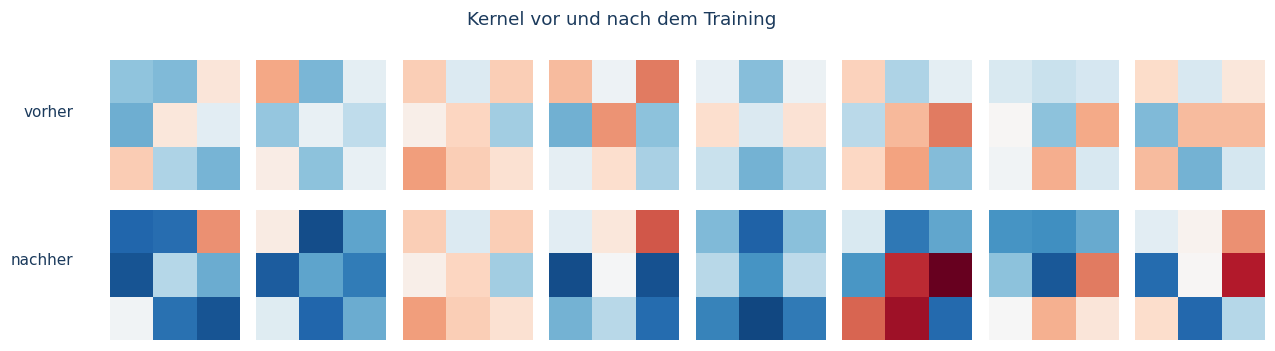

In [11]:
kernel_nachher = net[0].weight.detach()
vmax = max(kernel_vorher.abs().max().item(), kernel_nachher.abs().max().item())

fig, axs = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axs[0, i].imshow(kernel_vorher[i, 0],  cmap="RdBu", vmin=-vmax, vmax=vmax); axs[0, i].axis("off")
    axs[1, i].imshow(kernel_nachher[i, 0], cmap="RdBu", vmin=-vmax, vmax=vmax); axs[1, i].axis("off")
fig.text(0.5, 0.97, "Kernel vor und nach dem Training", ha="center", color=DUNKELBLAU, fontsize=12)
fig.text(0.085, 0.72, "vorher",  va="center", ha="right", color=DUNKELBLAU)
fig.text(0.085, 0.30, "nachher", va="center", ha="right", color=DUNKELBLAU)
plt.tight_layout(rect=[0.10, 0, 1, 0.94]); plt.show()

### Confusion Matrix & Verwechslungen
Die Confusion Matrix zeigt, welche Ziffern verwechselt werden. Noch anschaulicher:
die **tatsächlich falsch erkannten Bilder** ansehen (w = wahr, v = vorhergesagt).

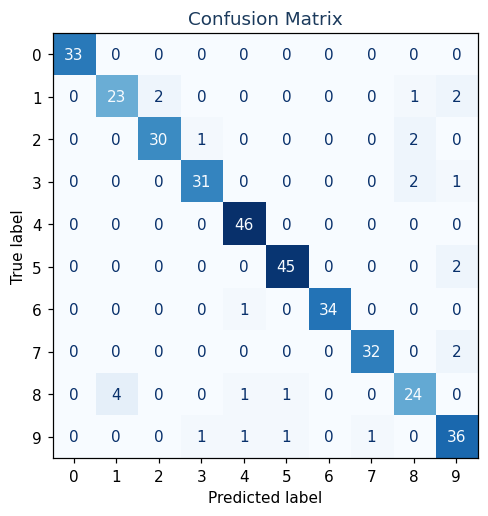

In [12]:
cm = confusion_matrix(y_test.numpy(), predicted.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix", color=DUNKELBLAU)
plt.tight_layout(); plt.show()

Fehlklassifikationen: 26 von 360 Testbildern


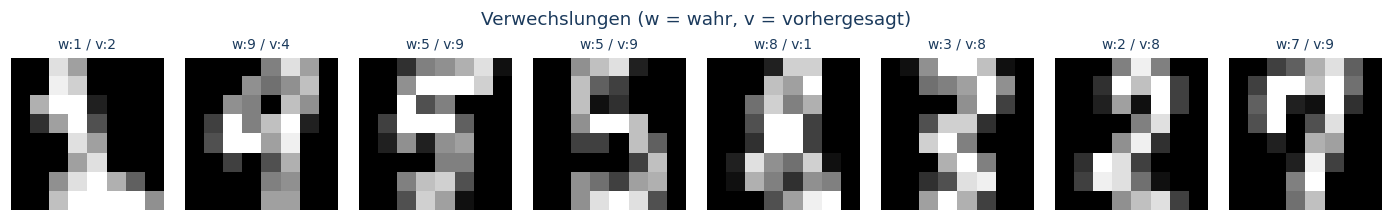

In [13]:
falsch = (predicted != y_test).nonzero(as_tuple=True)[0]
print(f"Fehlklassifikationen: {len(falsch)} von {len(y_test)} Testbildern")

anzahl = min(8, len(falsch))
if anzahl > 0:
    fig, axs = plt.subplots(1, anzahl, figsize=(1.6 * anzahl, 2))
    if anzahl == 1:
        axs = [axs]
    for j in range(anzahl):
        k = falsch[j].item()
        axs[j].imshow(X_test[k, 0], cmap="gray")
        axs[j].set_title(f"w:{y_test[k].item()} / v:{predicted[k].item()}", fontsize=9, color=DUNKELBLAU)
        axs[j].axis("off")
    fig.suptitle("Verwechslungen (w = wahr, v = vorhergesagt)", color=DUNKELBLAU)
    plt.tight_layout(); plt.show()
else:
    print("Keine Fehlklassifikationen – nichts zu zeigen.")

## Zur Vertiefung

- **Warum so wenige Parameter?** Der Conv-Layer hat nur `8 × (3×3) + 8 = 80`
  Gewichte – derselbe Kernel wird über das ganze Bild geschoben (*Weight Sharing*).
  Ein Dense-Layer mit vergleichbarer Wirkung bräuchte ein Vielfaches.
- **Experimentieren:** `idx` in Abschnitt 6 ändern → andere Eingabe; Anzahl der
  Filter (`8`) oder die Lernrate variieren und beobachten, wie sich Kernel und
  Genauigkeit verändern.
- **Nächste Schritte:** Notebook *04* (DataLoader, Early Stopping, Speichern/Laden),
  ein Notebook mit **synthetischen Mustern** (selbst gesetzter Kantenkernel als
  Konzeptbeweis) und optional **MNIST** (28×28) für zwei Conv-Stufen.